# FER2013: Facial Expression Recognition

## Cell 1: რეპოზიტორია და ინიციალიზაცია

In [7]:
import os, getpass

# Clone
!git clone https://github.com/GigiSichinava/ML-Assignment-4.git /content/ML-Assignment-4 2>/dev/null || echo "already cloned"
os.chdir('/content/ML-Assignment-4')
!pip install -q wandb kaggle

# Credentials
os.environ['KAGGLE_USERNAME'] = input('kaggle username: ').strip()
os.environ['KAGGLE_KEY']      = getpass.getpass('kaggle key: ').strip()
os.environ['WANDB_API_KEY']   = getpass.getpass('wandb key: ').strip()

# Data
import pandas as pd
os.makedirs('data', exist_ok=True)
if not os.path.exists('data/train.csv'):
    !kaggle datasets download -d deadskull7/fer2013 -p data/
    !unzip -q -o data/fer2013.zip -d data/
    df = pd.read_csv('data/fer2013.csv')
    df[df['Usage']=='Training'][['emotion','pixels']].to_csv('data/train.csv', index=False)
    df[df['Usage']!='Training'][['pixels']].to_csv('data/test.csv', index=False)
print('data ready:', os.listdir('data'))

# Wandb and Imports
import wandb
wandb.login()
import torch
from src.config import Config, PRESETS
from src.train import train_model
from src.utils import set_seed
device = 'cuda' if torch.cuda.is_available() else 'cpu'
set_seed(42)
print('ready, device:', device)

already cloned
kaggle username: gigisichinava
kaggle key: ··········
wandb key: ··········
Dataset URL: https://www.kaggle.com/datasets/deadskull7/fer2013
License(s): CC0-1.0
100% 96.6M/96.6M [00:00<00:00, 133MB/s]

data ready: ['fer2013.zip', 'fer2013.csv', 'test.csv', 'train.csv']
ready, device: cuda


## Cell 2: მონაცემები

In [ ]:
import os

os.makedirs('data', exist_ok=True)

if not os.path.exists('data/fer2013.csv'):
    !kaggle datasets download -d deadskull7/fer2013 -p data/
    !unzip -q -o data/fer2013.zip -d data/

import pandas as pd
if not os.path.exists('data/train.csv'):
    df = pd.read_csv('data/fer2013.csv')
    df[df['Usage'] == 'Training'][['emotion','pixels']].to_csv('data/train.csv', index=False)
    df[df['Usage'] != 'Training'][['pixels']].to_csv('data/test.csv', index=False)
    print('train.csv და test.csv შეიქმნა')
else:
    print('მონაცემები უკვე ადგილზეა')

!ls data/

მონაცემები უკვე ადგილზეა
fer2013.csv  fer2013.zip  test.csv  train.csv


## Cell 3: Wandb Login

In [ ]:
import wandb
wandb.login()
print('wandb ready')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: gsich23 (gsich23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb ready


## Cell 4: Sanity Check (forward და backward)
ეს ლექციაზე განხილული შემოწმებებია. initial loss ~ 1.946, tiny-batch overfit ~ 1.0 უნდა გამოვიდეს.

In [ ]:
import torch
from src.config import Config
from src.data import get_dataloaders
from src.models import get_model
from src.utils import set_seed, count_params, check_initial_loss, overfit_small_batch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)
set_seed(42)

cfg = Config(arch='SmallCNN')
train_loader, val_loader, test_loader, class_weights = get_dataloaders(cfg)
model = get_model(cfg).to(device)
print('params:', count_params(model))

# forward: random მოდელის loss ~ ln(7) = 1.946
check_initial_loss(model, train_loader, device)

# backward: 20 მაგალითზე ~100% train acc
overfit_small_batch(get_model(cfg).to(device), train_loader, device, n=20, steps=200)

device: cuda
params: 2426727
initial loss = 1.9443, expected ~ ln(7) = 1.9459
step   0: loss 2.0006, acc 0.050
step  50: loss 0.0002, acc 1.000
step 100: loss 0.0001, acc 1.000
step 150: loss 0.0001, acc 1.000
step 199: loss 0.0000, acc 1.000
final acc 20 მაგალითზე: 1.000 (უნდა იყოს ~1.0)


1.0

## Cell 5: ექსპერიმენტი N1: BaselineMLP (Underfit)
Flat ვექტორი, Spatial Info იკარგება. ველოდებით train და val acc ორივე დაბალს.

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


epoch   1: train 1.671/0.339, val 1.651/0.353, gap -0.014
epoch   2: train 1.549/0.400, val 1.566/0.382, gap +0.017
epoch   3: train 1.469/0.430, val 1.542/0.409, gap +0.021
epoch   4: train 1.396/0.458, val 1.509/0.424, gap +0.035
epoch   5: train 1.322/0.490, val 1.525/0.413, gap +0.077
epoch   6: train 1.246/0.520, val 1.536/0.416, gap +0.103
epoch   7: train 1.157/0.561, val 1.566/0.424, gap +0.137
epoch   8: train 1.069/0.596, val 1.622/0.441, gap +0.154
epoch   9: train 0.979/0.631, val 1.678/0.430, gap +0.201
epoch  10: train 0.879/0.668, val 1.725/0.439, gap +0.230
epoch  11: train 0.789/0.705, val 1.862/0.447, gap +0.259
epoch  12: train 0.700/0.739, val 1.945/0.424, gap +0.315
epoch  13: train 0.625/0.770, val 2.061/0.437, gap +0.333
epoch  14: train 0.544/0.801, val 2.230/0.440, gap +0.361
epoch  15: train 0.484/0.827, val 2.341/0.435, gap +0.391
epoch  16: train 0.426/0.847, val 2.463/0.443, gap +0.404
epoch  17: train 0.385/0.863, val 2.590/0.438, gap +0.425
epoch  18: tra

epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overfit_gap,▁▁▂▂▂▃▃▃▄▄▅▆▆▆▇▇▇▇▇██████
train/acc,▁▂▂▂▃▃▄▄▅▅▅▆▆▇▇▇▇▇███████
train/loss,█▇▇▇▆▆▆▅▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁▁
val/acc,▁▃▅▆▅▅▆▇▆▇▇▆▇▇▇▇▇▇█▇▇▇▇█▇
val/loss,▁▁▁▁▁▁▁▁▂▂▂▂▃▃▄▄▅▅▅▆▆▆▇██
best_val_acc,0.45489
epoch,25
final_overfit_gap,0.48299
lr,0.001


best val acc: 0.455


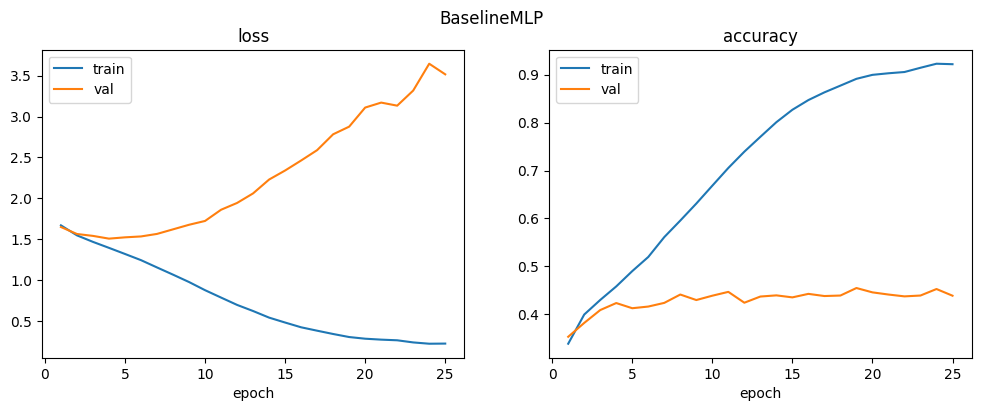

In [ ]:
from src.config import PRESETS
from src.train import train_model
from src.utils import plot_history

cfg = PRESETS['mlp_baseline']
model_mlp, history, best, (y_true, y_pred) = train_model(cfg, device=device)
plot_history(history, title='BaselineMLP')
print('best val acc:', round(best, 3))

## Cell 6: ექსპერიმენტი N2: SmallCNN
2 conv block + BatchNorm. CNN-ი spatial info-ს ინახავს, ამიტომ MLP-ზე კარგი უნდა იყოს.

epoch   1: train 1.884/0.272, val 1.671/0.358, gap -0.086
epoch   2: train 1.590/0.376, val 1.492/0.419, gap -0.043
epoch   3: train 1.482/0.425, val 1.390/0.461, gap -0.036
epoch   4: train 1.411/0.452, val 1.336/0.476, gap -0.024
epoch   5: train 1.362/0.473, val 1.280/0.506, gap -0.033
epoch   6: train 1.322/0.485, val 1.257/0.518, gap -0.032
epoch   7: train 1.298/0.496, val 1.237/0.531, gap -0.035
epoch   8: train 1.271/0.505, val 1.225/0.528, gap -0.023
epoch   9: train 1.244/0.515, val 1.218/0.534, gap -0.019
epoch  10: train 1.220/0.527, val 1.202/0.554, gap -0.027
epoch  11: train 1.201/0.529, val 1.201/0.548, gap -0.018
epoch  12: train 1.186/0.536, val 1.174/0.553, gap -0.016
epoch  13: train 1.162/0.546, val 1.149/0.565, gap -0.020
epoch  14: train 1.139/0.557, val 1.153/0.565, gap -0.008
epoch  15: train 1.127/0.559, val 1.151/0.566, gap -0.007
epoch  16: train 1.114/0.563, val 1.149/0.569, gap -0.005
epoch  17: train 1.096/0.570, val 1.134/0.572, gap -0.001
epoch  18: tra

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overfit_gap,▁▃▄▄▄▄▄▅▅▄▅▅▅▅▅▆▆▆▇▆▆▇▇▇███▇▇█
train/acc,▁▃▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇███████
train/loss,█▆▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val/acc,▁▃▄▄▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇█▇█████
val/loss,█▆▄▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁
best_val_acc,0.59596
epoch,30
final_overfit_gap,0.0388
lr,0.001


best val acc: 0.596


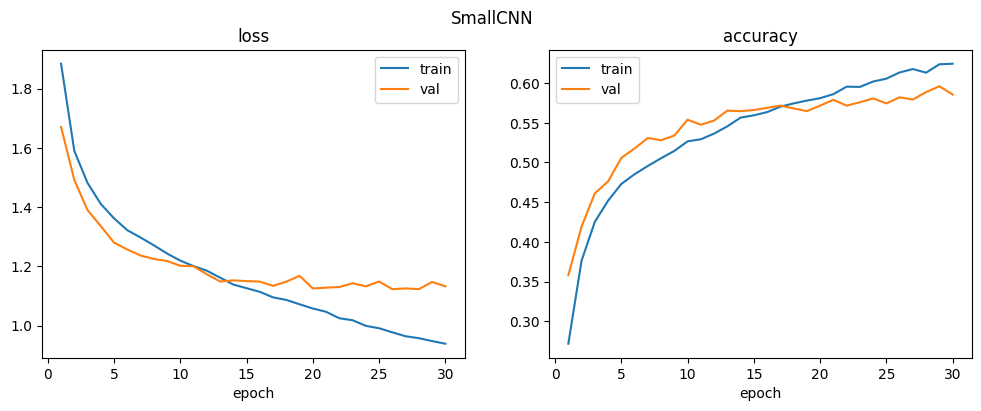

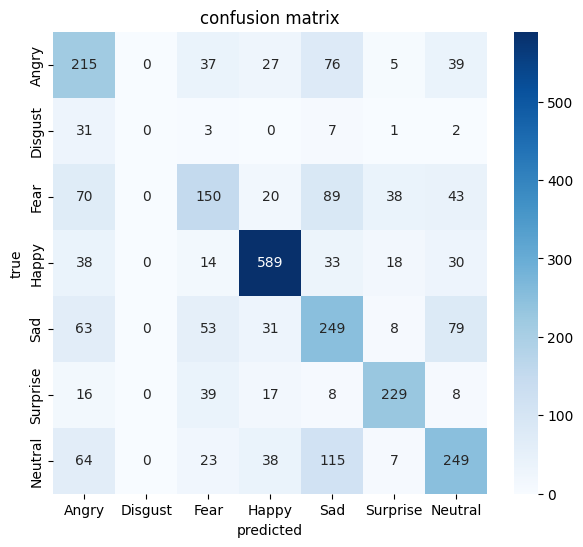

In [ ]:
from src.utils import plot_confusion

cfg = PRESETS['smallcnn']
model_small, history, best, (y_true, y_pred) = train_model(cfg, device=device)
plot_history(history, title='SmallCNN')
plot_confusion(y_true, y_pred)
print('best val acc:', round(best, 3))

## Cell 7: ექსპერიმენტი N3: DeeperCNN, regularization გარეშე (Overfit)
4 conv block, dropout=0, augmentation გამორთული. განზრახ overfit-ი: train acc >> val acc.

epoch   1: train 1.451/0.440, val 1.254/0.512, gap -0.072
epoch   2: train 1.156/0.561, val 1.178/0.558, gap +0.003
epoch   3: train 1.027/0.612, val 1.076/0.596, gap +0.016
epoch   4: train 0.927/0.648, val 1.086/0.602, gap +0.046
epoch   5: train 0.826/0.689, val 1.057/0.613, gap +0.076
epoch   6: train 0.713/0.734, val 1.180/0.601, gap +0.133
epoch   7: train 0.588/0.784, val 1.171/0.594, gap +0.190
epoch   8: train 0.449/0.839, val 1.456/0.563, gap +0.276
epoch   9: train 0.327/0.882, val 1.495/0.604, gap +0.278
epoch  10: train 0.220/0.925, val 1.760/0.596, gap +0.328
epoch  11: train 0.163/0.946, val 2.095/0.557, gap +0.389
epoch  12: train 0.122/0.963, val 1.845/0.612, gap +0.351
epoch  13: train 0.091/0.973, val 1.801/0.627, gap +0.346
epoch  14: train 0.087/0.973, val 1.980/0.622, gap +0.351
epoch  15: train 0.073/0.979, val 2.101/0.618, gap +0.361
epoch  16: train 0.063/0.982, val 2.016/0.626, gap +0.356
epoch  17: train 0.065/0.980, val 2.005/0.622, gap +0.358
epoch  18: tra

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overfit_gap,▁▂▂▃▃▄▅▆▆▇█▇▇▇█▇█▇▇███████████▇▇▇▇▇▇▇▇▇█
train/acc,▁▃▃▄▄▅▅▆▇▇▇█████████████████████████████
train/loss,█▇▆▅▅▄▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▃▅▆▆▆▅▄▆▅▃▆▇▇▆▇▇▇▇▇▇▆▇▇▆▆▇▇▇▇█████████▆
val/loss,▂▁▁▁▁▂▁▃▃▄▅▄▄▅▅▅▅▅▅▆▆▇▆▆▆▆▆▆▆▇▆▇▇▇▇▇▇▇▇█
best_val_acc,0.6496
epoch,40
final_overfit_gap,0.37931
lr,0.001


best val acc: 0.65


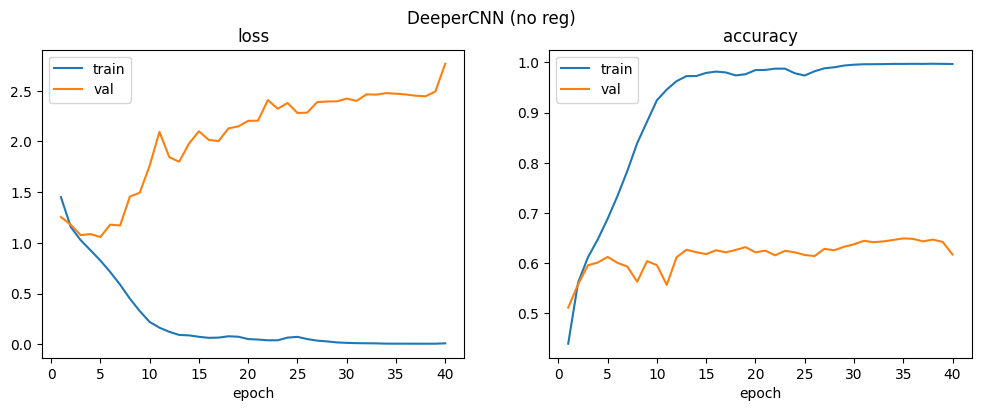

In [ ]:
cfg = PRESETS['deepcnn_overfit']
model_deep_ov, history, best, _ = train_model(cfg, device=device)
plot_history(history, title='DeeperCNN (no reg)')
print('best val acc:', round(best, 3))

## Cell 8: ექსპერიმენტი N4: DeeperCNN, regularized (Overfit-ის გასწორება)
dropout + weight decay + augmentation + cosine LR. overfit_gap-ი უნდა შემცირდეს.

epoch   1: train 1.936/0.201, val 1.902/0.202, gap -0.001
epoch   2: train 1.740/0.305, val 1.638/0.347, gap -0.041
epoch   3: train 1.533/0.409, val 1.526/0.429, gap -0.021
epoch   4: train 1.413/0.464, val 1.315/0.495, gap -0.031
epoch   5: train 1.334/0.488, val 1.292/0.504, gap -0.016
epoch   6: train 1.286/0.506, val 1.245/0.528, gap -0.023
epoch   7: train 1.234/0.525, val 1.250/0.510, gap +0.014
epoch   8: train 1.201/0.534, val 1.202/0.537, gap -0.003
epoch   9: train 1.163/0.550, val 1.115/0.552, gap -0.002
epoch  10: train 1.147/0.555, val 1.132/0.540, gap +0.014
epoch  11: train 1.115/0.564, val 1.192/0.583, gap -0.019
epoch  12: train 1.096/0.566, val 1.129/0.573, gap -0.007
epoch  13: train 1.079/0.578, val 1.076/0.590, gap -0.012
epoch  14: train 1.062/0.586, val 1.073/0.586, gap +0.001
epoch  15: train 1.048/0.589, val 1.076/0.593, gap -0.004
epoch  16: train 1.023/0.598, val 1.168/0.576, gap +0.022
epoch  17: train 1.007/0.601, val 1.065/0.595, gap +0.006
epoch  18: tra

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇████
lr,█████▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
overfit_gap,▃▁▂▂▂▃▄▂▃▃▃▄▃▃▆▄▄▄▅▄▆▅▆▆▆▆▆▇▇▇▇▇▇███████
train/acc,▁▃▃▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇██████████
train/loss,█▇▆▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val/acc,▁▃▄▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇█▇▇███████████████
val/loss,█▆▅▄▄▃▃▂▂▃▃▂▂▂▁▁▂▂▂▂▁▂▁▁▁▂▂▁▁▂▁▁▂▂▁▂▂▂▂▂
best_val_acc,0.69209
epoch,60
final_overfit_gap,0.07708
lr,0


best val acc: 0.692


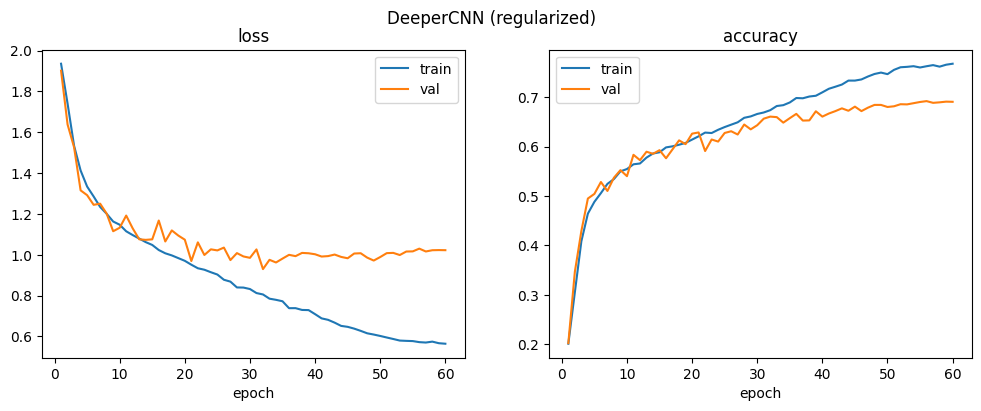

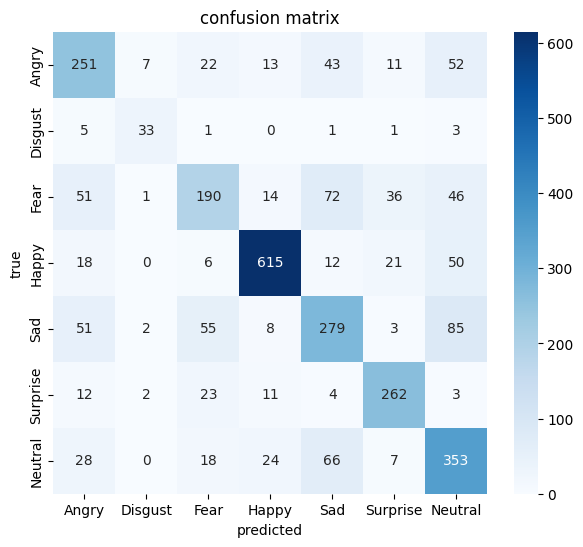

In [ ]:
cfg = PRESETS['deepcnn_regularized']
model_best, history, best, (y_true, y_pred) = train_model(cfg, device=device)
plot_history(history, title='DeeperCNN (regularized)')
plot_confusion(y_true, y_pred)
print('best val acc:', round(best, 3))

## Cell 9: ჰიპერპარამეტრების sweep: SmallCNN, სხვადასხვა lr

In [ ]:
from src.config import Config

for lr in [1e-2, 1e-3, 1e-4]:
    cfg = Config(arch='SmallCNN', run_name=f'smallcnn_lr{lr}',
                 lr=lr, dropout=0.25, epochs=25)
    _, history, best, _ = train_model(cfg, device=device)
    print(f'lr={lr}: best val acc = {round(best,3)}')

epoch   1: train 3.546/0.243, val 1.809/0.257, gap -0.013
epoch   2: train 1.806/0.254, val 1.803/0.255, gap -0.000
epoch   3: train 1.800/0.253, val 1.804/0.253, gap +0.000
epoch   4: train 1.776/0.269, val 1.734/0.294, gap -0.024
epoch   5: train 1.747/0.286, val 1.703/0.308, gap -0.021
epoch   6: train 1.731/0.290, val 1.690/0.305, gap -0.015
epoch   7: train 1.724/0.298, val 1.672/0.326, gap -0.029
epoch   8: train 1.709/0.311, val 1.642/0.342, gap -0.031
epoch   9: train 1.698/0.320, val 1.632/0.343, gap -0.024
epoch  10: train 1.686/0.332, val 1.624/0.371, gap -0.038
epoch  11: train 1.662/0.345, val 1.582/0.405, gap -0.060
epoch  12: train 1.632/0.358, val 1.518/0.415, gap -0.057
epoch  13: train 1.612/0.368, val 1.513/0.408, gap -0.039
epoch  14: train 1.596/0.375, val 1.465/0.442, gap -0.067
epoch  15: train 1.583/0.382, val 1.487/0.425, gap -0.043
epoch  16: train 1.564/0.389, val 1.447/0.430, gap -0.041
epoch  17: train 1.561/0.393, val 1.459/0.418, gap -0.026
epoch  18: tra

epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overfit_gap,▇██▅▆▆▅▅▆▄▂▂▄▁▃▄▅▆▄▃▃▄▅▂▅
train/acc,▁▁▁▂▃▃▃▄▄▅▅▆▆▆▇▇▇▇▇▇▇████
train/loss,█▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val/acc,▁▁▁▂▃▃▃▄▄▅▆▆▆▇▇▇▆▆▇▇▇▇▇█▇
val/loss,███▇▆▆▆▆▅▅▅▄▄▃▃▃▃▃▃▂▁▁▁▁▁
best_val_acc,0.46778
epoch,25
final_overfit_gap,-0.03005
lr,0.01


lr=0.01: best val acc = 0.468


epoch   1: train 1.885/0.272, val 1.668/0.358, gap -0.086
epoch   2: train 1.591/0.376, val 1.493/0.419, gap -0.043
epoch   3: train 1.482/0.425, val 1.385/0.461, gap -0.035
epoch   4: train 1.413/0.450, val 1.327/0.480, gap -0.030
epoch   5: train 1.359/0.471, val 1.267/0.519, gap -0.048
epoch   6: train 1.323/0.485, val 1.251/0.531, gap -0.046
epoch   7: train 1.296/0.494, val 1.233/0.539, gap -0.045
epoch   8: train 1.268/0.508, val 1.212/0.533, gap -0.025
epoch   9: train 1.242/0.517, val 1.203/0.539, gap -0.022
epoch  10: train 1.223/0.523, val 1.197/0.560, gap -0.037
epoch  11: train 1.200/0.531, val 1.171/0.563, gap -0.032
epoch  12: train 1.184/0.536, val 1.165/0.556, gap -0.020
epoch  13: train 1.157/0.547, val 1.139/0.576, gap -0.029
epoch  14: train 1.142/0.551, val 1.149/0.567, gap -0.017
epoch  15: train 1.128/0.558, val 1.150/0.562, gap -0.004
epoch  16: train 1.116/0.563, val 1.142/0.572, gap -0.009
epoch  17: train 1.095/0.572, val 1.133/0.573, gap -0.001
epoch  18: tra

epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overfit_gap,▁▄▄▄▃▃▃▅▅▄▄▅▄▅▆▆▆▆▇▇▇▇▇▇█
train/acc,▁▃▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇██████
train/loss,█▆▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁
val/acc,▁▃▄▅▆▆▇▆▇▇▇▇█▇▇███▇██████
val/loss,█▆▄▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▂
best_val_acc,0.5869
epoch,25
final_overfit_gap,0.03079
lr,0.001


lr=0.001: best val acc = 0.587


epoch   1: train 1.679/0.334, val 1.584/0.396, gap -0.062
epoch   2: train 1.533/0.410, val 1.461/0.435, gap -0.025
epoch   3: train 1.441/0.449, val 1.411/0.451, gap -0.002
epoch   4: train 1.370/0.477, val 1.348/0.483, gap -0.007
epoch   5: train 1.315/0.498, val 1.292/0.506, gap -0.007
epoch   6: train 1.277/0.511, val 1.267/0.519, gap -0.008
epoch   7: train 1.246/0.527, val 1.234/0.537, gap -0.011
epoch   8: train 1.211/0.542, val 1.223/0.541, gap +0.001
epoch   9: train 1.178/0.557, val 1.199/0.549, gap +0.009
epoch  10: train 1.152/0.568, val 1.181/0.549, gap +0.019
epoch  11: train 1.128/0.573, val 1.177/0.551, gap +0.023
epoch  12: train 1.100/0.588, val 1.163/0.565, gap +0.023
epoch  13: train 1.078/0.594, val 1.147/0.572, gap +0.022
epoch  14: train 1.052/0.609, val 1.139/0.579, gap +0.030
epoch  15: train 1.030/0.618, val 1.132/0.574, gap +0.044
epoch  16: train 1.012/0.624, val 1.115/0.584, gap +0.039
epoch  17: train 0.995/0.631, val 1.127/0.584, gap +0.047
epoch  18: tra

epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overfit_gap,▁▃▄▃▃▃▃▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇██
train/acc,▁▂▃▄▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇████
train/loss,█▇▆▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁
val/acc,▁▂▃▄▅▅▆▆▆▆▆▇▇▇▇█▇█▇█▇████
val/loss,█▆▆▅▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
best_val_acc,0.59875
epoch,25
final_overfit_gap,0.09481
lr,0.0001


lr=0.0001: best val acc = 0.599


## Cell 10: ჰიპერპარამეტრების Sweep, DeeperCNN, სხვადასხვა Dropout

In [8]:
for d in [0.0, 0.3, 0.5]:
    cfg = Config(arch='DeeperCNN', run_name=f'deepcnn_drop{d}',
                 dropout=d, weight_decay=1e-4, augment=True,
                 scheduler='cosine', epochs=40)
    _, history, best, _ = train_model(cfg, device=device)
    print(f'dropout={d}: best val acc = {round(best,3)}')

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


epoch   1: train 1.551/0.393, val 1.338/0.470, gap -0.077
epoch   2: train 1.230/0.527, val 1.299/0.499, gap +0.028
epoch   3: train 1.120/0.572, val 1.167/0.555, gap +0.017
epoch   4: train 1.066/0.595, val 1.105/0.573, gap +0.022
epoch   5: train 1.014/0.616, val 1.024/0.606, gap +0.009
epoch   6: train 0.982/0.626, val 1.007/0.611, gap +0.015
epoch   7: train 0.946/0.641, val 1.099/0.582, gap +0.059
epoch   8: train 0.918/0.654, val 1.048/0.596, gap +0.058
epoch   9: train 0.899/0.659, val 1.063/0.598, gap +0.061
epoch  10: train 0.870/0.673, val 1.007/0.607, gap +0.066
epoch  11: train 0.848/0.681, val 1.002/0.622, gap +0.059
epoch  12: train 0.825/0.688, val 1.000/0.630, gap +0.057
epoch  13: train 0.798/0.699, val 0.930/0.669, gap +0.031
epoch  14: train 0.783/0.708, val 0.958/0.651, gap +0.056
epoch  15: train 0.756/0.719, val 1.008/0.643, gap +0.076
epoch  16: train 0.730/0.728, val 0.942/0.667, gap +0.061
epoch  17: train 0.705/0.739, val 0.931/0.654, gap +0.085
epoch  18: tra

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,██████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
overfit_gap,▁▃▃▃▃▃▄▄▄▄▄▄▃▄▄▄▄▅▄▅▅▅▆▆▆▆▆▇▇▇▇▇████████
train/acc,▁▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇█████████
train/loss,█▆▆▆▅▅▅▅▅▅▅▄▄▄▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val/acc,▁▂▄▄▅▅▄▅▅▅▆▆▇▆▆▇▆▆▇▇▇▇▇▇▇█▇██▇██████████
val/loss,█▇▅▄▃▂▄▃▃▂▂▂▁▁▂▁▁▁▁▁▂▂▂▂▂▃▄▄▄▄▅▅▅▅▆▆▆▆▆▆
best_val_acc,0.70463
epoch,40
final_overfit_gap,0.25632
lr,0


dropout=0.0: best val acc = 0.705


epoch   1: train 1.631/0.362, val 1.321/0.490, gap -0.128
epoch   2: train 1.305/0.498, val 1.261/0.512, gap -0.014
epoch   3: train 1.192/0.545, val 1.165/0.552, gap -0.008
epoch   4: train 1.136/0.568, val 1.091/0.585, gap -0.017
epoch   5: train 1.094/0.584, val 1.077/0.586, gap -0.002
epoch   6: train 1.061/0.598, val 1.026/0.615, gap -0.018
epoch   7: train 1.029/0.613, val 1.031/0.606, gap +0.007
epoch   8: train 1.007/0.619, val 1.035/0.599, gap +0.020
epoch   9: train 0.986/0.626, val 1.029/0.614, gap +0.012
epoch  10: train 0.972/0.632, val 0.989/0.621, gap +0.011
epoch  11: train 0.947/0.643, val 0.983/0.637, gap +0.006
epoch  12: train 0.925/0.651, val 0.979/0.629, gap +0.021
epoch  13: train 0.910/0.659, val 0.935/0.648, gap +0.011
epoch  14: train 0.896/0.663, val 0.942/0.639, gap +0.024
epoch  15: train 0.872/0.670, val 0.972/0.649, gap +0.021
epoch  16: train 0.858/0.679, val 0.918/0.647, gap +0.032
epoch  17: train 0.842/0.683, val 0.913/0.658, gap +0.026
epoch  18: tra

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,██████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
overfit_gap,▁▄▄▄▅▄▅▅▅▅▅▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇███████
train/acc,▁▃▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇█████████
train/loss,█▆▅▅▅▄▄▄▄▄▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val/acc,▁▂▃▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇█▇▇████████████
val/loss,█▇▆▅▄▄▄▄▄▃▃▃▂▂▃▂▂▁▁▂▂▂▁▂▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂▂
best_val_acc,0.69836
epoch,40
final_overfit_gap,0.11981
lr,0


dropout=0.3: best val acc = 0.698


epoch   1: train 1.736/0.312, val 1.585/0.374, gap -0.062
epoch   2: train 1.388/0.466, val 1.340/0.473, gap -0.007
epoch   3: train 1.258/0.519, val 1.197/0.528, gap -0.009
epoch   4: train 1.199/0.541, val 1.153/0.561, gap -0.021
epoch   5: train 1.153/0.562, val 1.108/0.571, gap -0.009
epoch   6: train 1.120/0.572, val 1.094/0.582, gap -0.010
epoch   7: train 1.089/0.584, val 1.092/0.584, gap -0.000
epoch   8: train 1.062/0.599, val 1.020/0.599, gap -0.001
epoch   9: train 1.044/0.603, val 1.034/0.607, gap -0.004
epoch  10: train 1.030/0.612, val 1.020/0.603, gap +0.009
epoch  11: train 1.007/0.622, val 1.028/0.614, gap +0.008
epoch  12: train 0.991/0.625, val 1.003/0.618, gap +0.006
epoch  13: train 0.978/0.635, val 0.943/0.641, gap -0.006
epoch  14: train 0.965/0.637, val 0.970/0.635, gap +0.002
epoch  15: train 0.948/0.646, val 0.969/0.639, gap +0.007
epoch  16: train 0.931/0.651, val 0.940/0.644, gap +0.007
epoch  17: train 0.921/0.656, val 0.914/0.658, gap -0.002
epoch  18: tra

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,██████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
overfit_gap,▁▄▄▃▄▄▄▄▄▅▅▄▄▄▅▅▄▄▅▅▅▅▅▆▅▆▆▆▆▇▇▇▇▇█▇████
train/acc,▁▃▄▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇███████████
train/loss,█▆▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▃▄▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇███████████████████
val/loss,█▆▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_acc,0.6907
epoch,40
final_overfit_gap,0.06958
lr,0


dropout=0.5: best val acc = 0.691


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Cell 11: Kaggle submission (საუკეთესო მოდელით)

In [11]:
import os, getpass, torch, wandb
from src.config import PRESETS
from src.train import train_model, make_submission
from src.utils import set_seed

# Setup
os.chdir('/content/ML-Assignment-4')
os.environ['WANDB_API_KEY'] = getpass.getpass('wandb key: ').strip()
wandb.login()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
set_seed(42)

# Best Model
cfg = PRESETS['deepcnn_regularized']
model_best, history, best, _ = train_model(cfg, device=device)
print('best val acc:', round(best, 3))

# Submission
make_submission(model_best, cfg, out_path='submission.csv', device=device)

wandb key: ··········


epoch   1: train 1.911/0.214, val 1.697/0.295, gap -0.081
epoch   2: train 1.640/0.358, val 1.940/0.310, gap +0.048
epoch   3: train 1.458/0.445, val 1.383/0.485, gap -0.040
epoch   4: train 1.381/0.474, val 1.282/0.500, gap -0.026
epoch   5: train 1.306/0.498, val 1.230/0.518, gap -0.020
epoch   6: train 1.269/0.510, val 1.225/0.529, gap -0.020
epoch   7: train 1.226/0.525, val 1.204/0.514, gap +0.010
epoch   8: train 1.197/0.531, val 1.183/0.532, gap -0.001
epoch   9: train 1.164/0.547, val 1.173/0.532, gap +0.015
epoch  10: train 1.143/0.552, val 1.134/0.553, gap -0.002
epoch  11: train 1.115/0.564, val 1.199/0.584, gap -0.020
epoch  12: train 1.103/0.565, val 1.109/0.589, gap -0.024
epoch  13: train 1.082/0.575, val 1.101/0.595, gap -0.020
epoch  14: train 1.069/0.584, val 1.126/0.583, gap +0.000
epoch  15: train 1.045/0.586, val 1.084/0.581, gap +0.005
epoch  16: train 1.018/0.597, val 1.034/0.596, gap +0.001
epoch  17: train 1.007/0.603, val 1.081/0.598, gap +0.005
epoch  18: tra

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇████
lr,███████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁
overfit_gap,▁▇▃▃▄▄▄▄▅▅▅▄▅▅▄▇▅▅▆▅▆▆▆▆▆▇▇▆▇▇▇█████████
train/acc,▁▄▄▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇███████████
train/loss,█▇▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▁▅▅▅▆▆▆▆▆▇▆▇▆▇▇▇▇▇▇▇▇█▇████████████████
val/loss,▆█▄▃▃▃▃▃▃▂▂▂▁▂▂▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_acc,0.68722
epoch,60
final_overfit_gap,0.07639
lr,0


best val acc: 0.687
submission შენახულია: submission.csv, 7178 row


'submission.csv'